[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLO26 Object Detection on a Custom Dataset

---

[![roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/how-to-train-yolo26-custom-data/) [![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

YOLO26 introduces a unified architecture designed to support detection, segmentation, and pose tasks within a single model family. The model uses an anchor-free design with a decoupled head.

## Setup

### Configure API keys

To fine-tune YOLO26, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Runtime` -> `Change runtime type` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Thu Jun 25 13:14:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


### Install dependencies required for YOLO26

In [3]:
%pip install -q "ultralytics>=8.4.0" supervision roboflow

# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


## Fine-tune YOLO26 on custom dataset

**NOTE:** When training YOLO26, make sure your data is located in `datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`. In this tutorial, we will use one of the [datasets](https://universe.roboflow.com/liangdianzhong/-qvdww) available on [Roboflow Universe](https://universe.roboflow.com/). When downloading, make sure to select the `yolov11` export format.

In [34]:
import os

!mkdir -p {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("dimas-edra-ar-rafi")
project = workspace.project("salak-3zra9")
version = project.version(2)
dataset = version.download("yolo26")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Salak-2 in yolo26:: 100%|██████████| 881/881 [00:00<00:00, 10005.42it/s]


## Custom Training

In [ ]:
%cd {HOME}

# Menjalankan training ulang dengan dataset v2
!yolo task=detect mode=train model=yolo26m.pt data={dataset.location}/data.yaml epochs=20 imgsz=640 plots=True

/content
Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/Salak-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, op

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [10]:
!ls {HOME}/runs/detect/train/

args.yaml			 labels.jpg	     train_batch341.jpg
BoxF1_curve.png			 results.csv	     train_batch342.jpg
BoxP_curve.png			 results.png	     val_batch0_labels.jpg
BoxPR_curve.png			 train_batch0.jpg    val_batch0_pred.jpg
BoxR_curve.png			 train_batch1.jpg    weights
confusion_matrix_normalized.png  train_batch2.jpg
confusion_matrix.png		 train_batch340.jpg


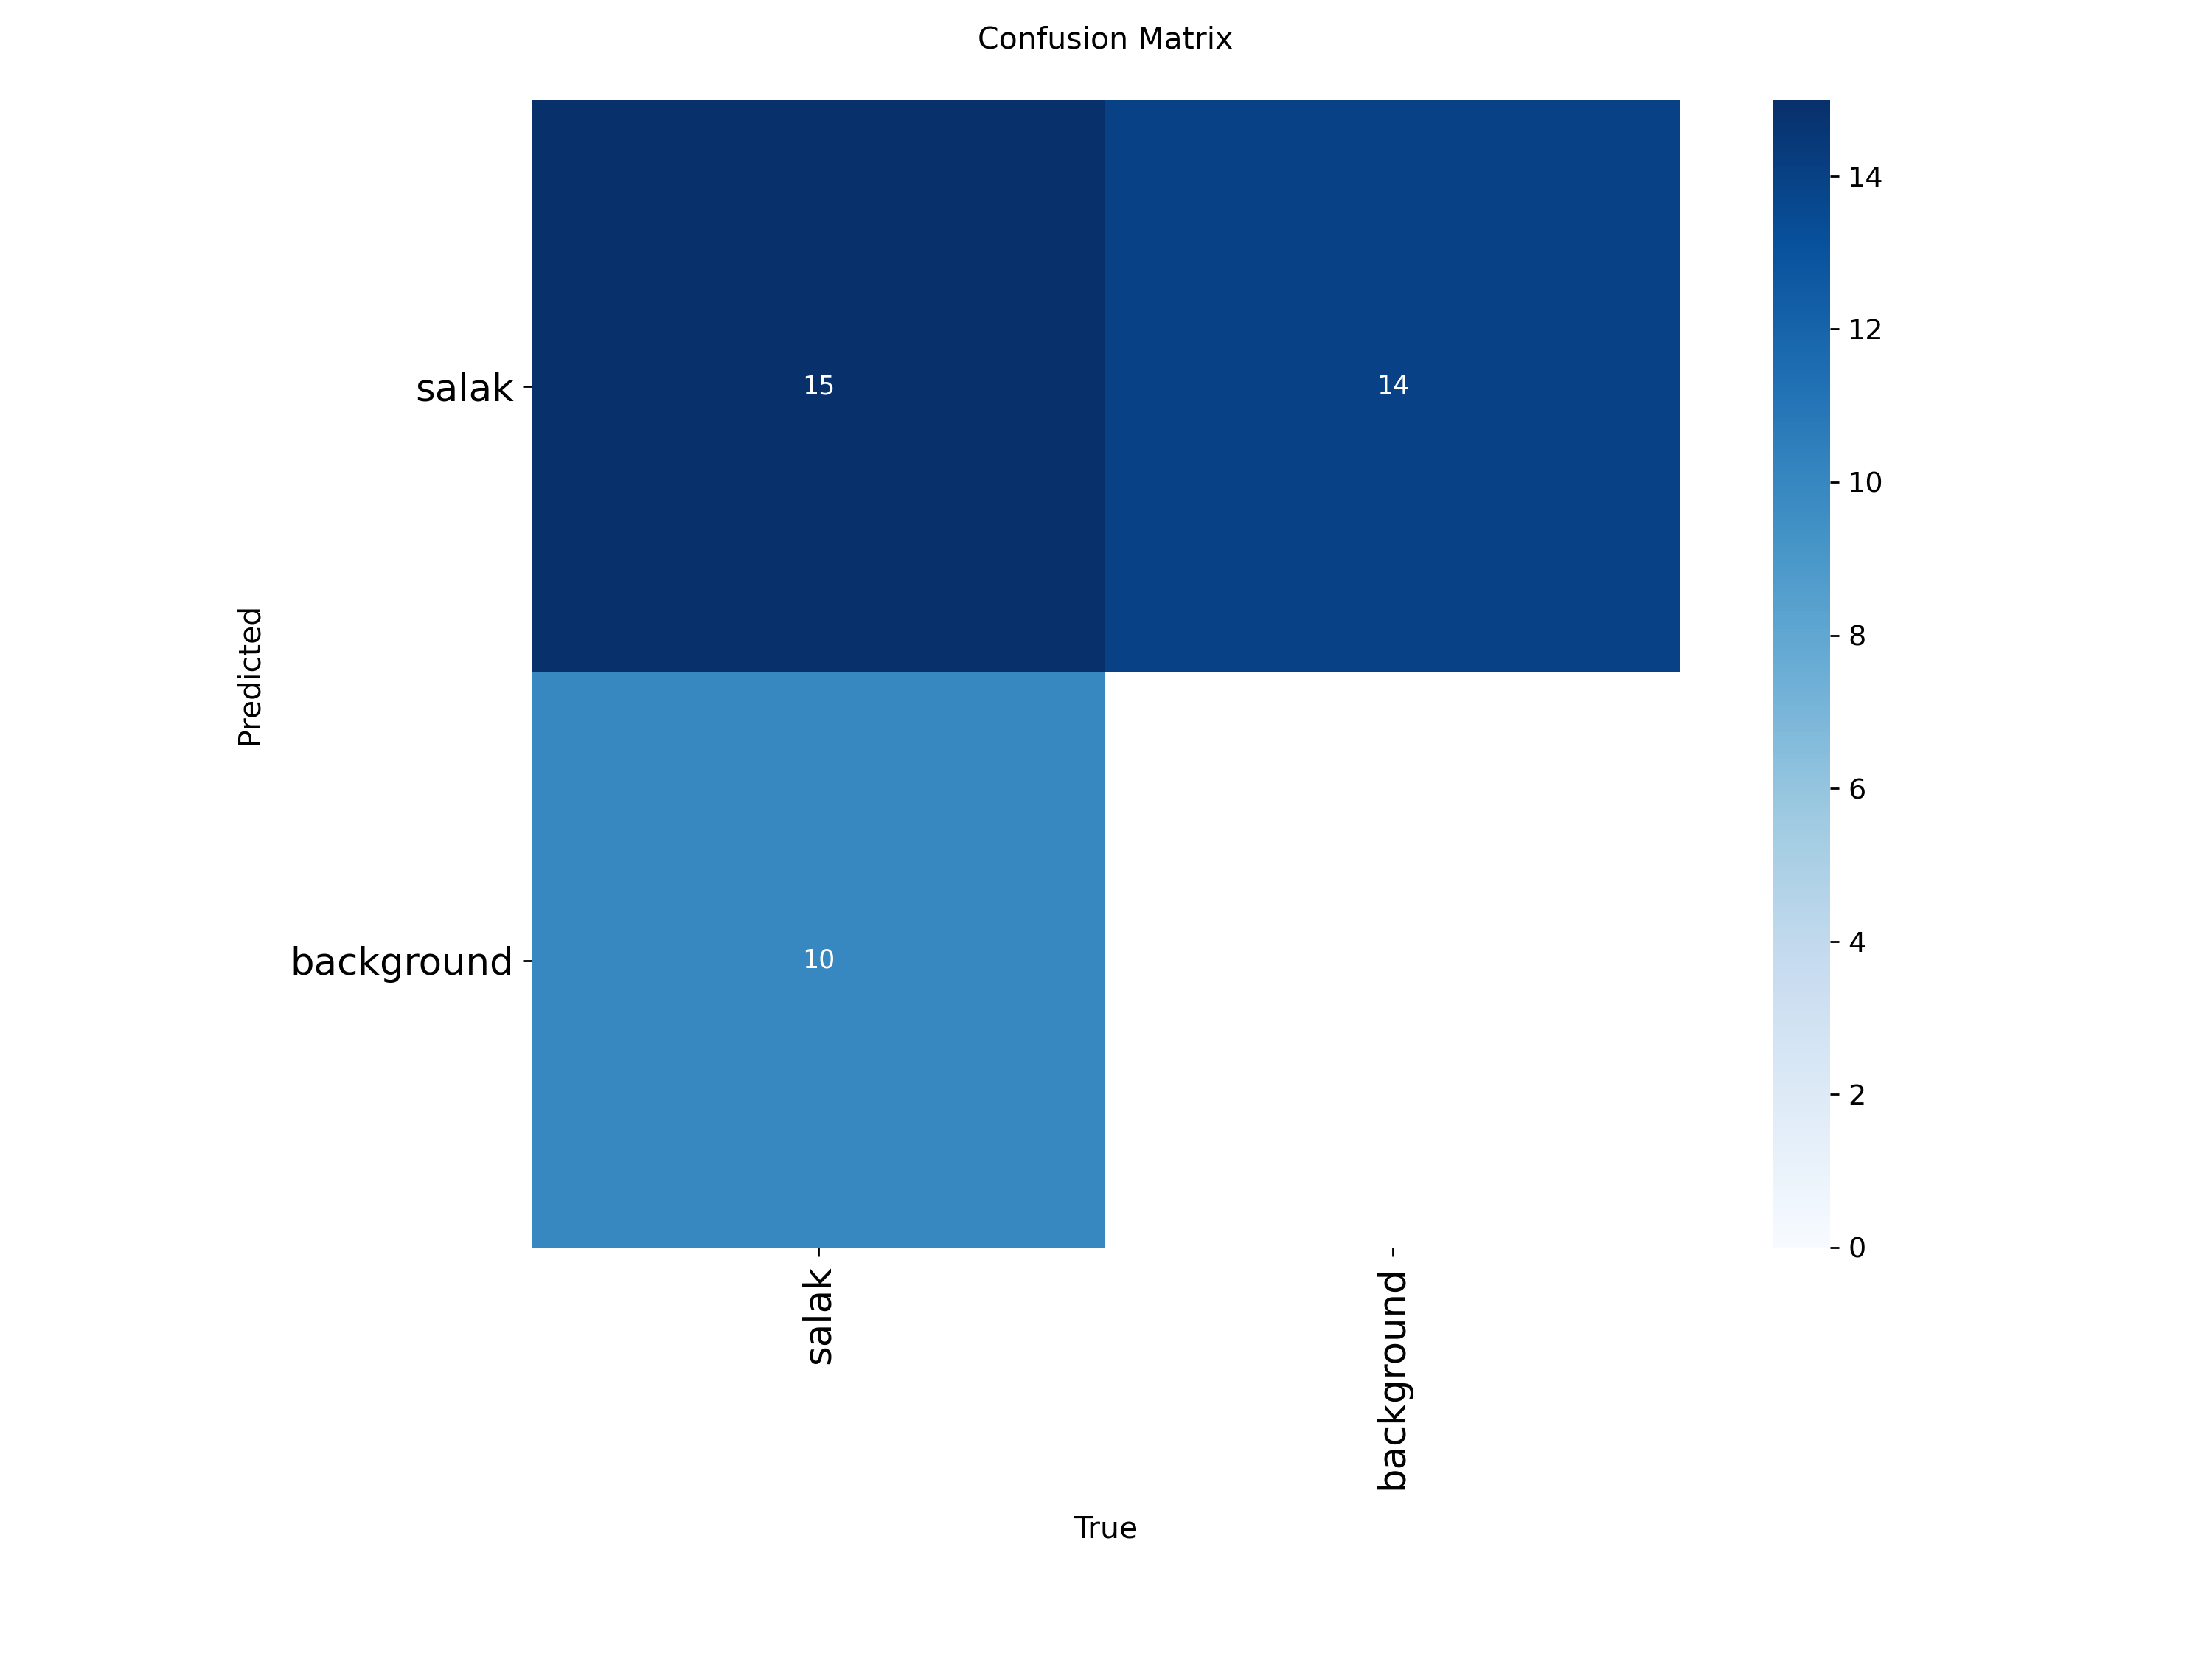

In [11]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

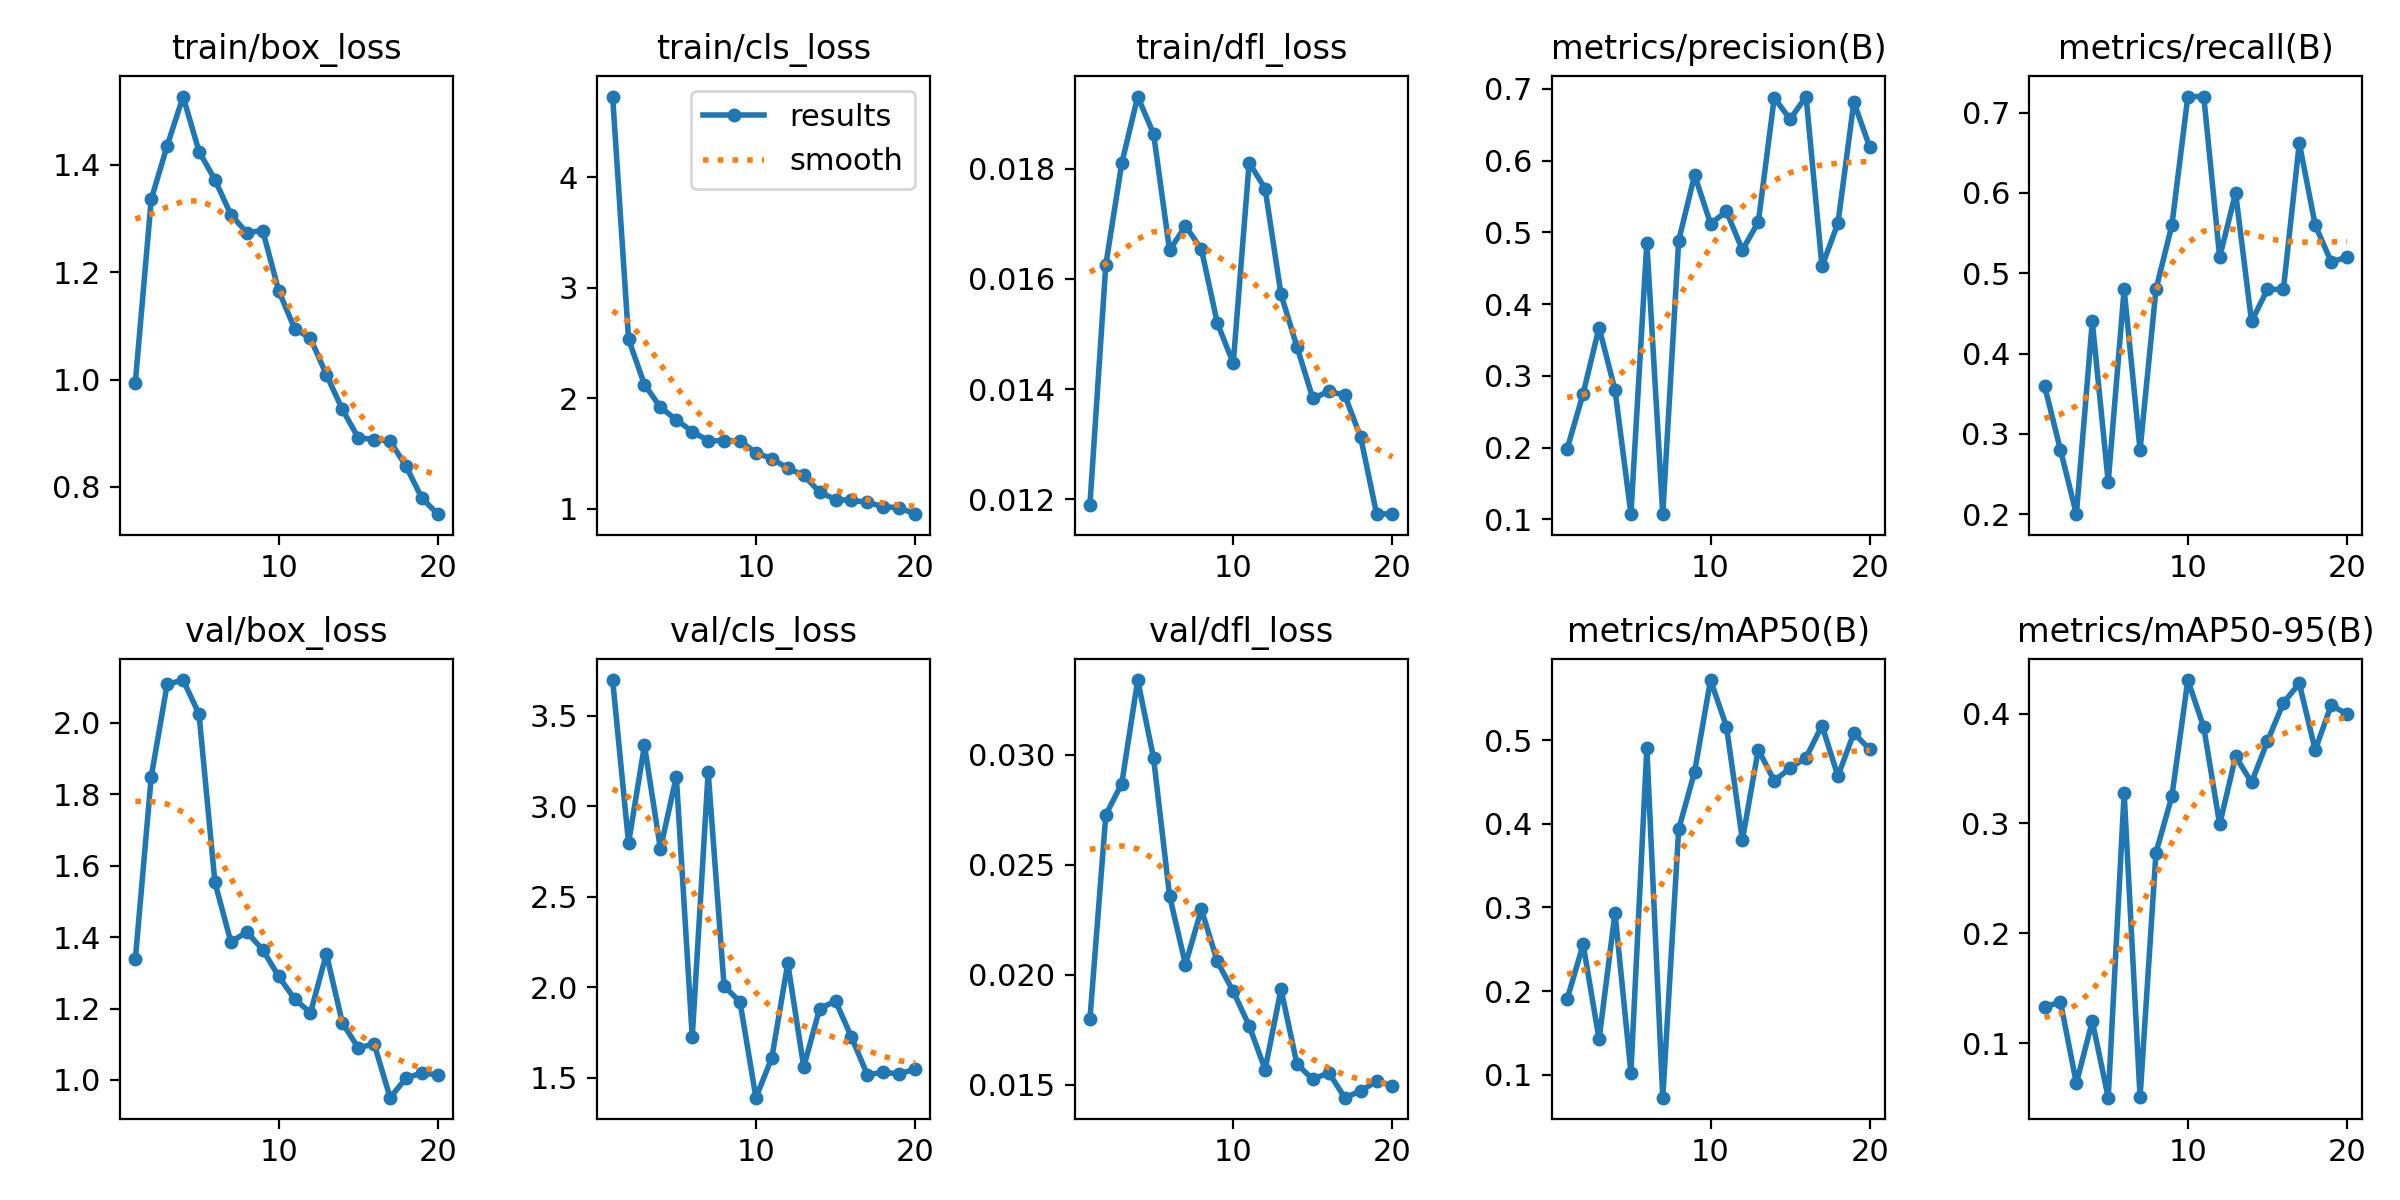

In [12]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

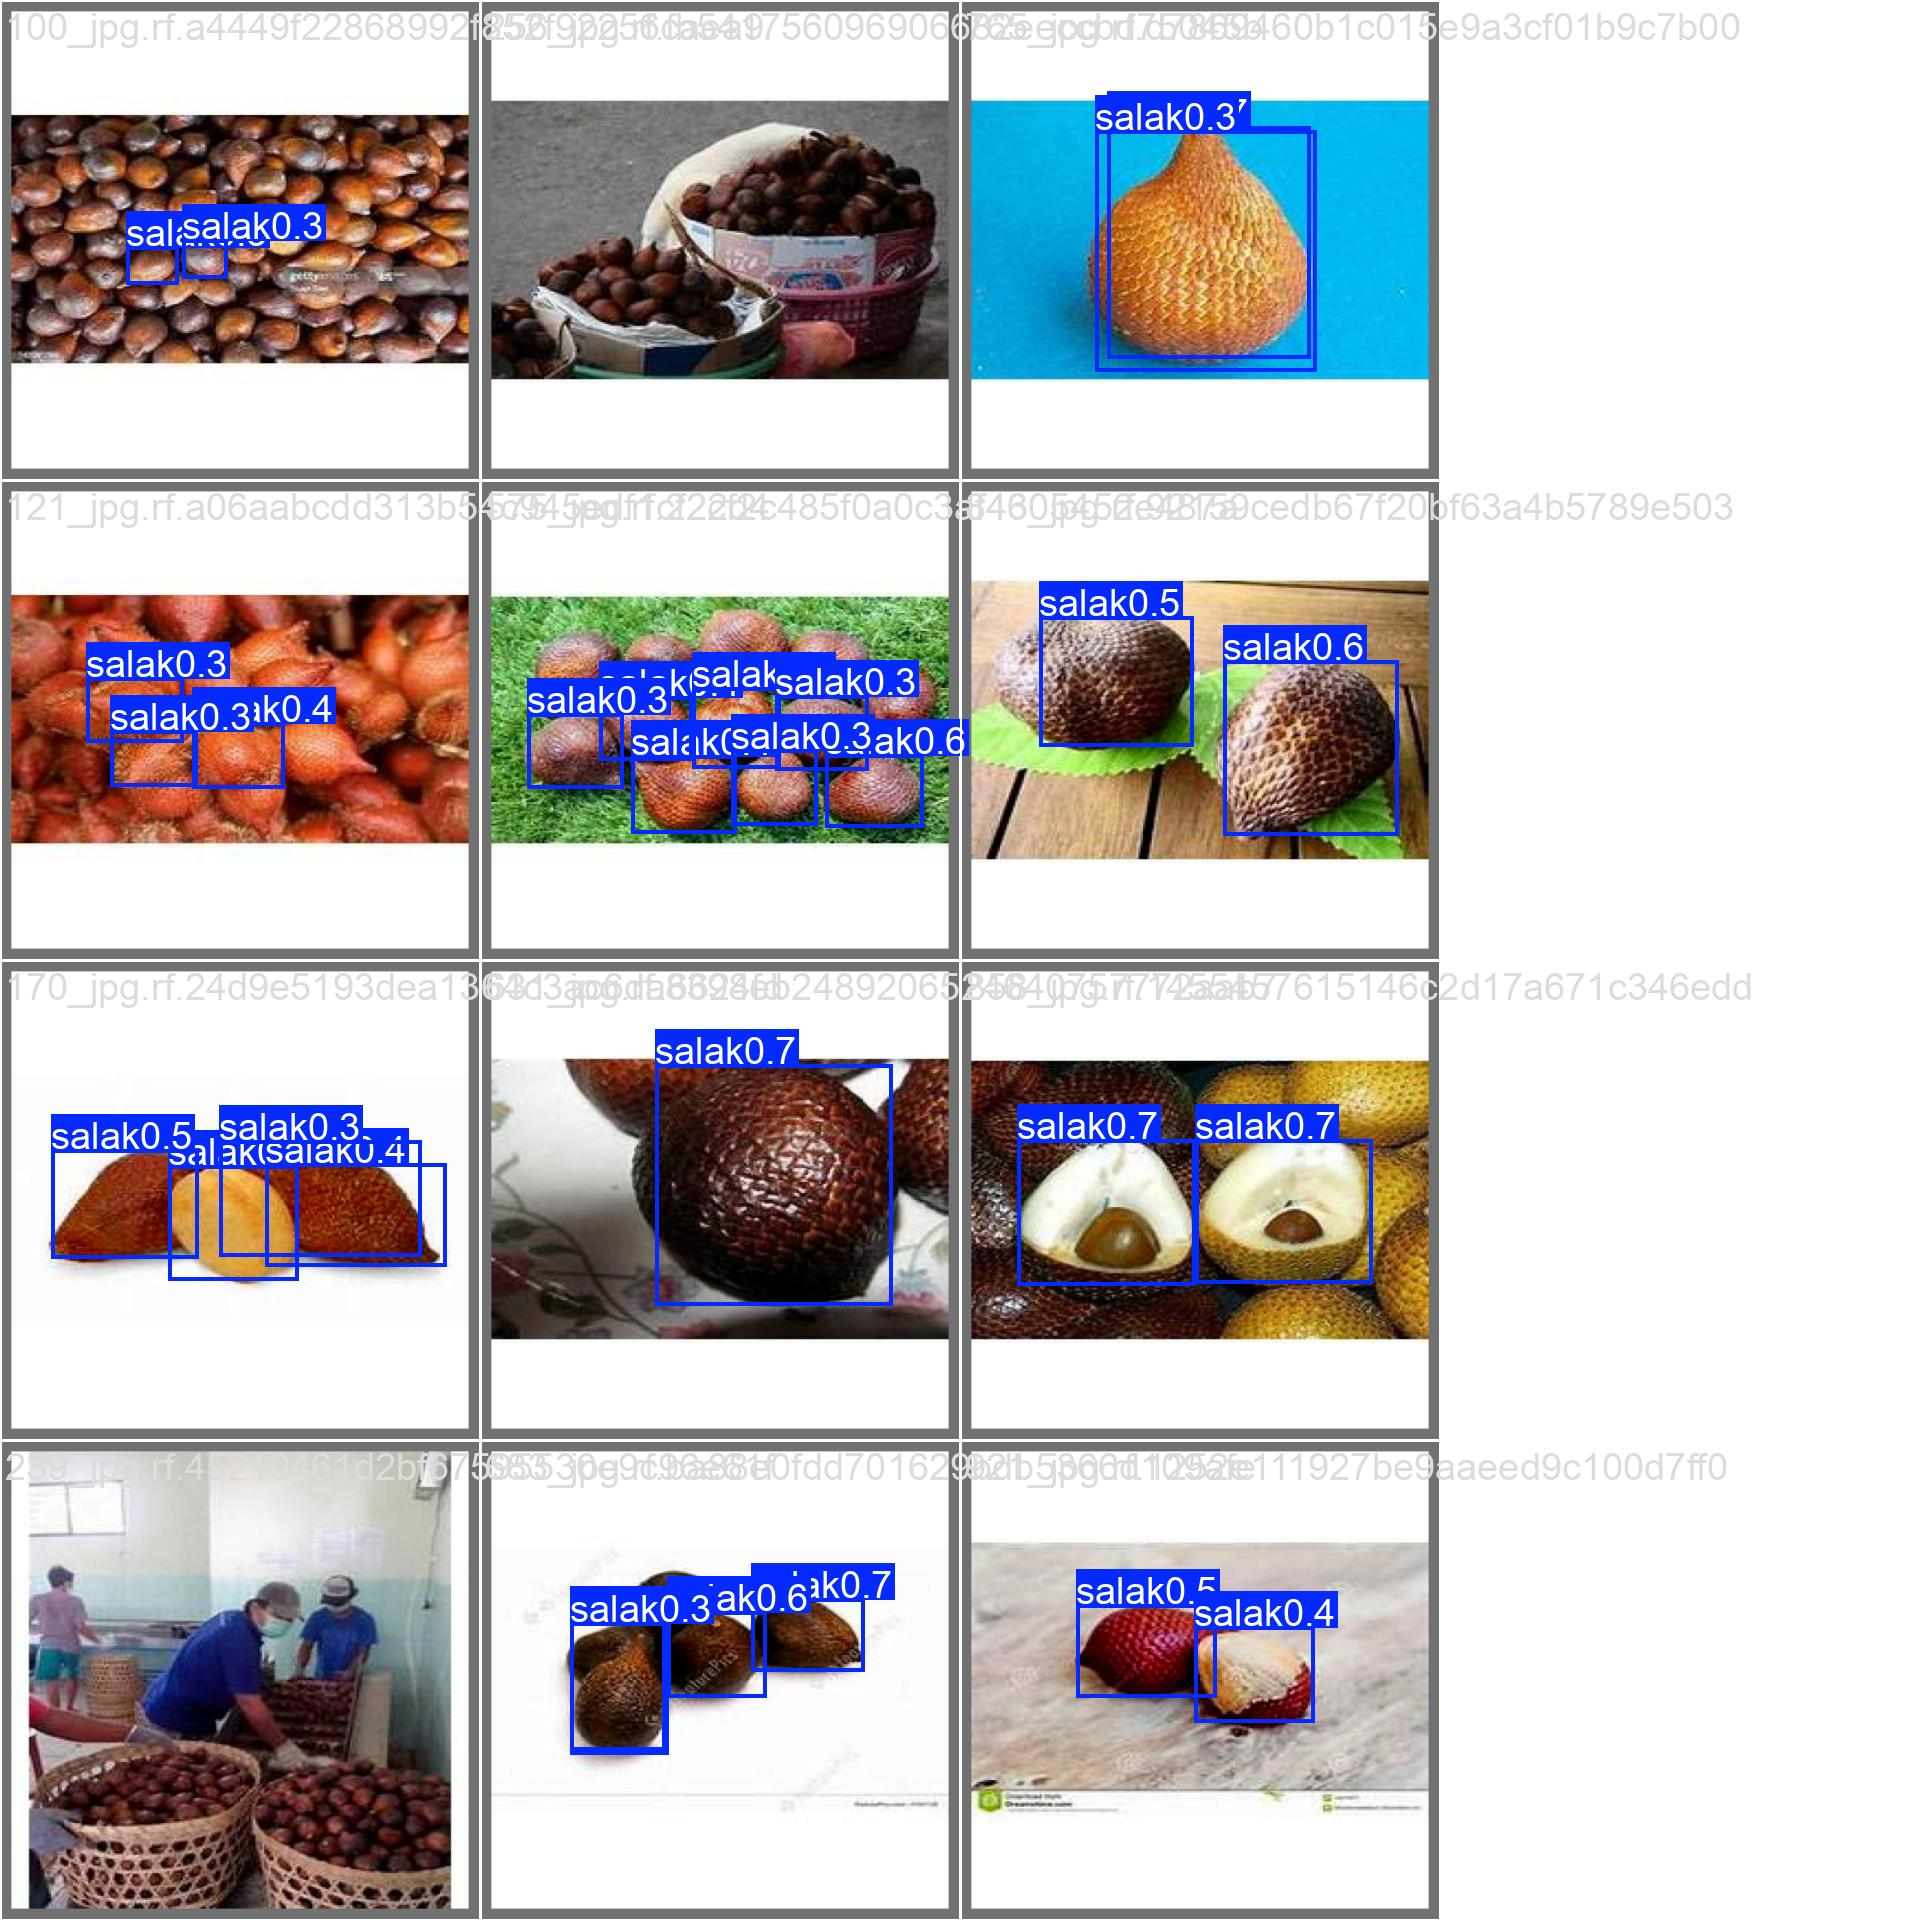

In [20]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [24]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1115.2±236.7 MB/s, size: 26.4 KB)
val: Scanning /content/datasets/Salak-1/valid/labels.cache... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12 2.2Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 21, len(boxes) = 25. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.9it/s 0.5s
                   all         12         25      0.512       0.72      0.571       0.43
Speed: 0.8ms preprocess, 31.1ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/runs/detect/val-3


### Mengecek Performa pada Test Set
Jika dataset Anda memiliki folder `test`, kita bisa menjalankan perintah validasi tapi diarahkan ke split `test` untuk mendapatkan laporan akurasi final.

In [25]:
# Menjalankan validasi pada data test
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml split=test

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/data/base.py", line 176, in get_img_files
    raise FileNotFoundError(f"{self.prefix}{p} does not exist")
FileNotFoundError: val: /content/datasets/Salak-1/test/images does not exist

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 1038, in entrypoint
    getattr(model, mode)(**overrides)  # default args from model
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 615, in val
    validator(model=self.model)
  File "/usr

In [22]:
!ls -R {dataset.location}

/content/datasets/Salak-1:
data.yaml  README.dataset.txt  README.roboflow.txt  train  valid

/content/datasets/Salak-1/train:
images	labels	labels.cache

/content/datasets/Salak-1/train/images:
1001_jpg.rf.02dbdf173b4fec0d76f735fcdf5e1551.jpg
1001_jpg.rf.70255ebe86dbf6d1a98b3c1f51be6ea0.jpg
1001_jpg.rf.7535e4753771fb38ac52c69850ba693b.jpg
1003_jpg.rf.e6431a53e3096e04de0ec867f304fe3b.jpg
1003_jpg.rf.f16ff275f67ea6793150b4a7a3048d58.jpg
1003_jpg.rf.f76d755d08b318936e8c1ac89888b3c3.jpg
1004_jpg.rf.59d094b11ae43acdbf914213e5a1d336.jpg
1004_jpg.rf.73f39bdf1d60e9e53c6da2eb2d1d41fa.jpg
1004_jpg.rf.b4e78bfd2de64b9d3b1802ad14e95764.jpg
1005_jpg.rf.0d69669b0ecb18bb5ab48c413b342820.jpg
1005_jpg.rf.1483e3b9747ea41b1d85b85018f229c1.jpg
1005_jpg.rf.6b0a9b7304e0476ef705592549614da0.jpg
1006_jpg.rf.01addb39c3fcf4f6387def7b0c50f7c3.jpg
1006_jpg.rf.a675f286dca5bc15dea3be151247795e.jpg
1006_jpg.rf.ca677945fbf107fb713148052de0ce52.jpg
1011_jpg.rf.0a423bc71a90a2155ef876515df10d6d.jpg
1011_jpg.rf.0f0340a0d5

In [23]:
# Cek isi file konfigurasi dataset untuk melihat pembagian folder
!cat {dataset.location}/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['salak']

roboflow:
  workspace: dimas-edra-ar-rafi
  project: salak-3zra9
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/dimas-edra-ar-rafi/salak-3zra9/dataset/1

## Inference with custom model

### CLI

In [15]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt source={dataset.location}/test/images save=True verbose=False

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs
Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 1038, in entrypoint
    getattr(model, mode)(**overrides)  # default args from model
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 537, in predict
    return self.predictor.predict_cli(source=source) if is_cli else self.predictor(source=source, stream=stream)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/predictor.py", line 247, in predict_cli
    for _ in gen:  # sourcery skip: remove-empty-nested-block, noqa
             ^^^
  File "/usr/local/lib/python3.

### SDK

In [28]:
from ultralytics import YOLO

model = YOLO(f'{HOME}/runs/detect/train/weights/best.pt')

In [29]:
import supervision as sv

# Kita arahkan ke folder 'valid' karena folder 'test' kosong di dataset ini
ds_test = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/valid/images",
    annotations_directory_path=f"{dataset.location}/valid/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)

print(f"Jumlah gambar yang siap diuji: {len(ds_test)}")

Jumlah gambar yang siap diuji: 12


In [30]:
import supervision as sv
from PIL import Image

def annotate(image: Image.Image, detections: sv.Detections) -> Image.Image:
    color = sv.ColorPalette.from_hex([
        "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00",
        "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    ])

    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)

    box_annotator = sv.BoxAnnotator(color=color)
    label_annotator = sv.LabelAnnotator(
        color=color,
        text_color=sv.Color.BLACK,
        text_scale=text_scale,
        smart_position=True
    )

    out = image.copy()
    out = box_annotator.annotate(out, detections)
    out = label_annotator.annotate(out, detections)
    out.thumbnail((1000, 1000))
    return out

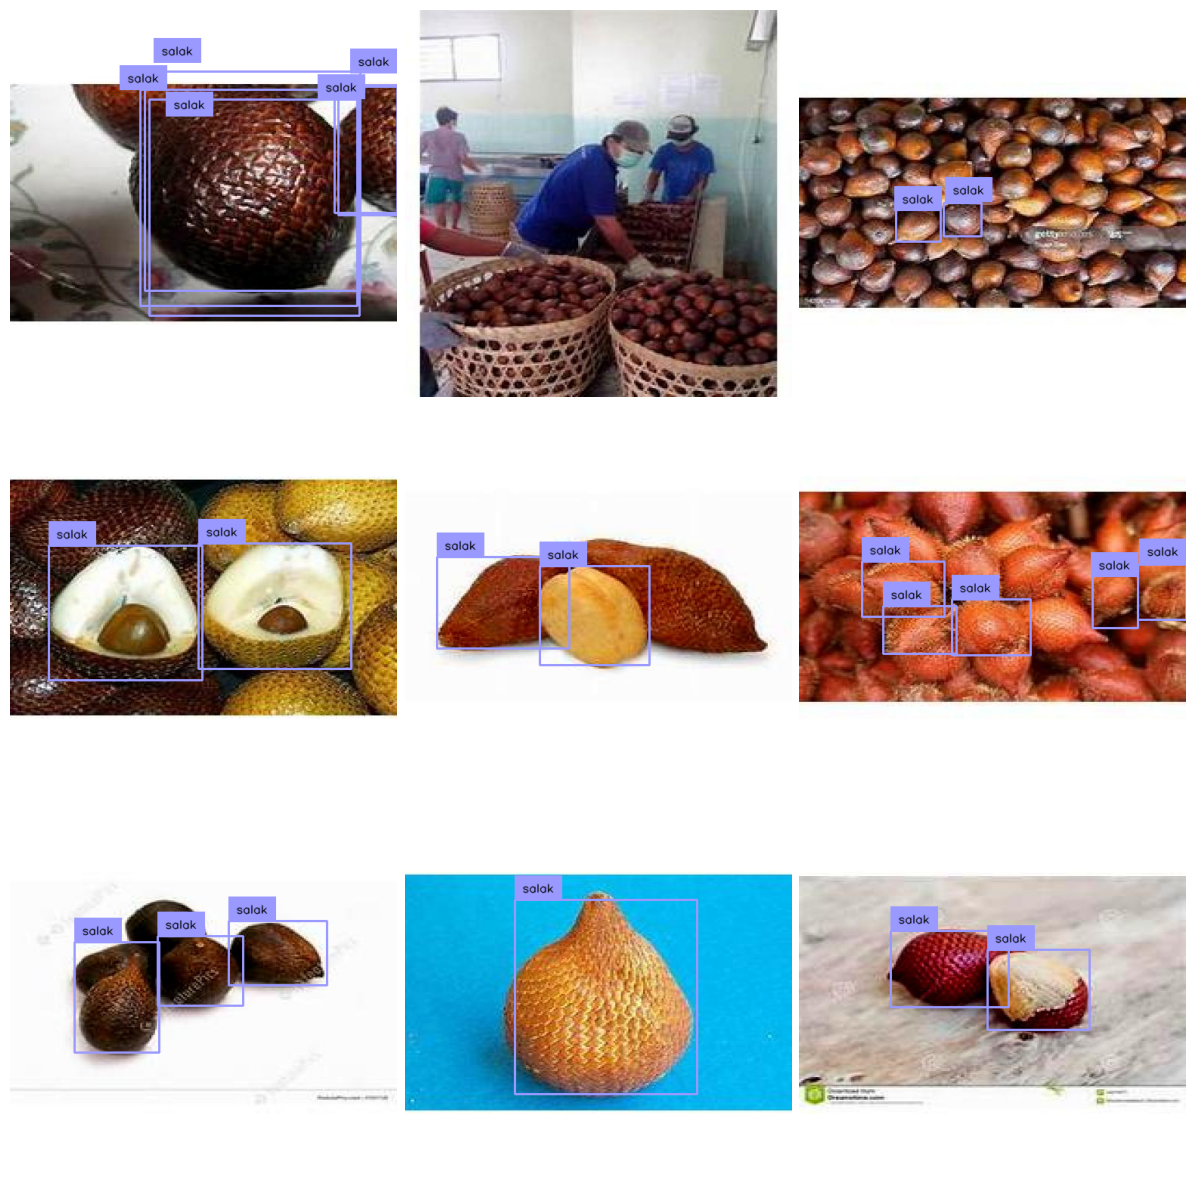

In [31]:
import random
import matplotlib.pyplot as plt

# Menyesuaikan N agar tidak melebihi jumlah gambar yang ada
L = len(ds_test)
N = min(9, L)

annotated_images = []

if L > 0:
    for i in random.sample(range(L), N):
        path, _, annotations = ds_test[i]
        image = Image.open(path)
        result = model.predict(image, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(result)
        annotated_image = annotate(image, detections)
        annotated_images.append(annotated_image)

    fig, axes = plt.subplots(3, 3, figsize=(12, 12))

    for ax, img in zip(axes.flat, annotated_images):
        ax.imshow(img)
        ax.axis("off")

    plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0.01, right=0.99, top=0.99, bottom=0.01)
    plt.show()
else:
    print("Tidak ada gambar untuk ditampilkan.")

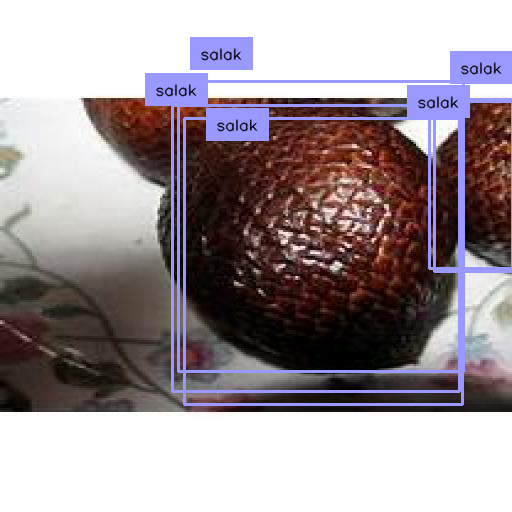

In [33]:
annotated_images[0]

## Deploy model on Roboflow

Upload the YOLO26 weights to Roboflow Deploy for inference on Roboflow infrastructure built for scale.

In [ ]:
project.version(dataset.version).deploy(model_type="yolo26", model_path=f"{HOME}/runs/detect/train/")

View the status of your deployment at: https://app.roboflow.com/roboflow-jvuqo/basketball-player-detection-3-ycjdo/14
Share your model with the world at: https://universe.roboflow.com/roboflow-jvuqo/basketball-player-detection-3-ycjdo/model/14


## Run inference with a Roboflow hosted model

Load a trained model from Roboflow and run inference.

In [ ]:
!pip install -q inference

In [ ]:
from inference import get_model
from google.colab import userdata

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

model_id = project.id.split("/")[1] + "/" + dataset.version
model = get_model(model_id, ROBOFLOW_API_KEY)

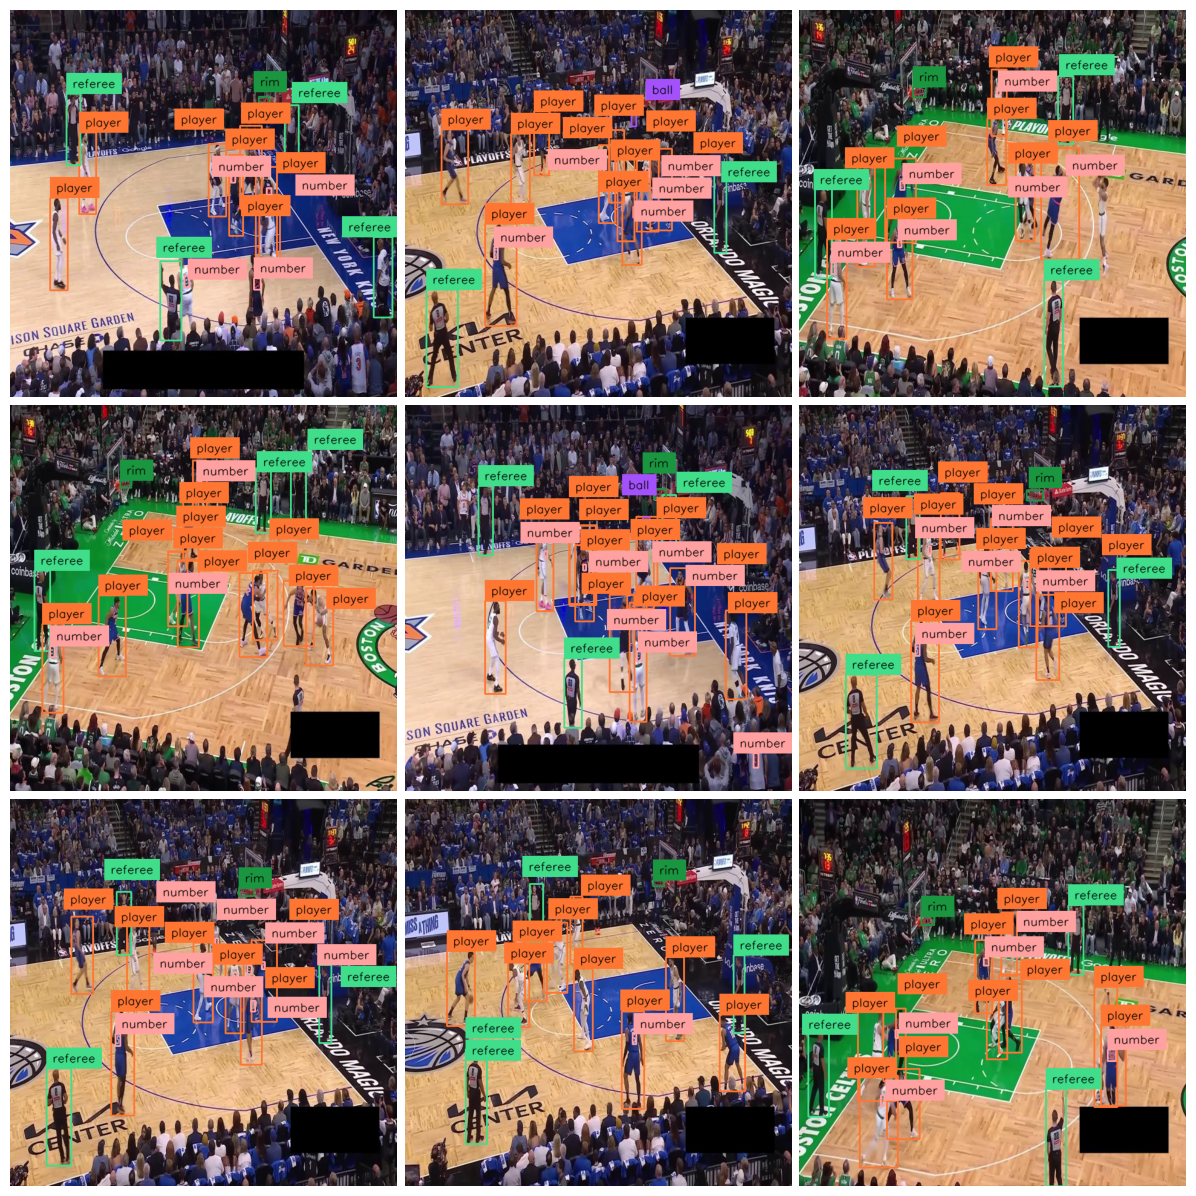

In [ ]:
import random
import matplotlib.pyplot as plt

N = 9
L = len(ds_test)

annotated_images = []

for i in random.sample(range(L), N):
    path, _, annotations = ds_test[i]
    image = Image.open(path)
    result = model.infer(image)[0]
    detections = sv.Detections.from_inference(result)
    annotated_image = annotate(image, detections)
    annotated_images.append(annotated_image)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, img in zip(axes.flat, annotated_images):
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0.01, right=0.99, top=0.99, bottom=0.01)

plt.show()

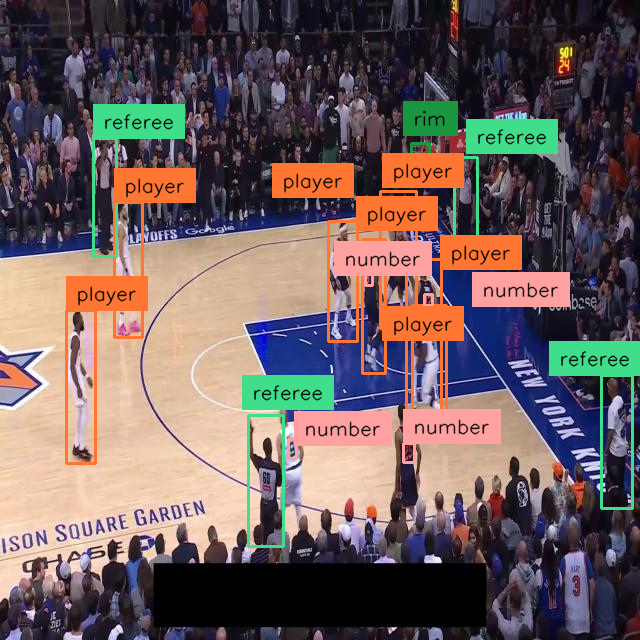

In [ ]:
annotated_images[0]

## Real-time Inference using Webcam

Karena Colab berjalan di cloud, kita tidak bisa menggunakan `cv2.VideoCapture(0)` secara langsung. Kita akan menggunakan cuplikan kode JavaScript untuk menjembatani kamera lokal Anda dengan kernel Colab.

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
from PIL import Image
import io

def video_stream():
  js = Javascript('''
    var video;
    var div = null;
    var stream;
    var captureCanvas;
    var imgElement;
    var labelElement;

    var pendingResolve = null;
    var shutdown = false;

    function removeDom() {
       stream.getTracks().forEach(track => track.stop());
       video.remove();
       div.remove();
       video = null;
       div = null;
    }

    function onAnimationFrame() {
      if (!shutdown) {
        window.requestAnimationFrame(onAnimationFrame);
      }
      if (pendingResolve) {
        var result = ""
        if (!shutdown) {
          captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
          result = captureCanvas.toDataURL('image/jpeg', 0.8)
        }
        var lp = pendingResolve;
        pendingResolve = null;
        lp(result);
      }
    }

    async function createDom() {
      if (div !== null) {
        return;
      }

      div = document.createElement('div');
      div.style.border = '2px solid black';
      div.style.padding = '10px';
      div.style.width = '640px';
      div.style.margin = '0 auto';

      video = document.createElement('video');
      video.style.display = 'block';
      video.width = 640;
      video.height = 480;
      video.autoplay = true;
      div.appendChild(video);

      imgElement = document.createElement('img');
      imgElement.style.position = 'absolute';
      imgElement.style.zIndex = '1';
      div.appendChild(imgElement);

      const stopButton = document.createElement('button');
      stopButton.textContent = 'Stop Camera';
      div.appendChild(stopButton);
      stopButton.onclick = () => { shutdown = true; };

      document.body.appendChild(div);

      stream = await navigator.mediaDevices.getUserMedia({video: {facingMode: 'environment'}});
      video.srcObject = stream;

      await video.play();

      captureCanvas = document.createElement('canvas');
      captureCanvas.width = 640;
      captureCanvas.height = 480;
      window.requestAnimationFrame(onAnimationFrame);
    }

    async function takePhoto() {
      await createDom();

      if (shutdown) {
        removeDom();
        shutdown = false;
        return "";
      }

      return new Promise((resolve, reject) => {
        pendingResolve = resolve;
      });
    }
    ''')
  display(js)

def video_frame():
  data = eval_js('takePhoto()')
  return data

# Muat model terbaik kita
model = YOLO(f'{HOME}/runs/detect/train/weights/best.pt')

video_stream()

while True:
    frame_js = video_frame()
    if not frame_js:
        break

    # Decode frame
    img_bytes = b64decode(frame_js.split(',')[1])
    img = Image.open(io.BytesIO(img_bytes))
    frame = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

    # Inference
    results = model.predict(frame, conf=0.5, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)

    # Annotate
    annotated_frame = annotate(img, detections)

    # Display (Karena loop di Colab, kita butuh cara untuk update image di output)
    # Namun untuk performa live, biasanya kita tampilkan preview di JavaScript.
    # Untuk kemudahan, kita tampilkan satu frame yang sudah dideteksi.
    display(annotated_frame)
    from IPython.display import clear_output
    clear_output(wait=True)

## Inference on Uploaded Video

Gunakan blok ini jika Anda ingin mengunggah video salak (misal: salak di konveyor) dan melihat hasil deteksinya.

In [ ]:
from google.colab import files
import os

# 1. Upload video
print("Silahkan pilih file video salak Anda:")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
video_path_abs = os.path.abspath(video_path)

# 2. Run Inference pada video tersebut
# Hasil akan disimpan di folder runs/detect/predict
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt source={video_path_abs} save=True

### Menampilkan atau Mendownload Hasil Video
Setelah proses di atas selesai, video hasil deteksi akan muncul di folder `runs/detect/predict`. Anda bisa mendownloadnya dengan kode di bawah ini.

In [ ]:
# Cari file video terbaru hasil prediksi
import glob

latest_predict_dir = max(glob.glob(f'{HOME}/runs/detect/predict*'), key=os.path.getmtime)
predicted_video = glob.glob(f'{latest_predict_dir}/*.mp4')[0]

print(f"Video hasil deteksi ada di: {predicted_video}")

# Download ke perangkat Anda
files.download(predicted_video)

<div align="center">
  <p>
    Looking for more tutorials or have questions?
    Check out our <a href="https://github.com/roboflow/notebooks">GitHub repo</a> for more notebooks,
    or visit our <a href="https://discord.gg/GbfgXGJ8Bk">discord</a>.
  </p>
  
  <p>
    <strong>If you found this helpful, please consider giving us a ⭐
    <a href="https://github.com/roboflow/notebooks">on GitHub</a>!</strong>
  </p>

</div>